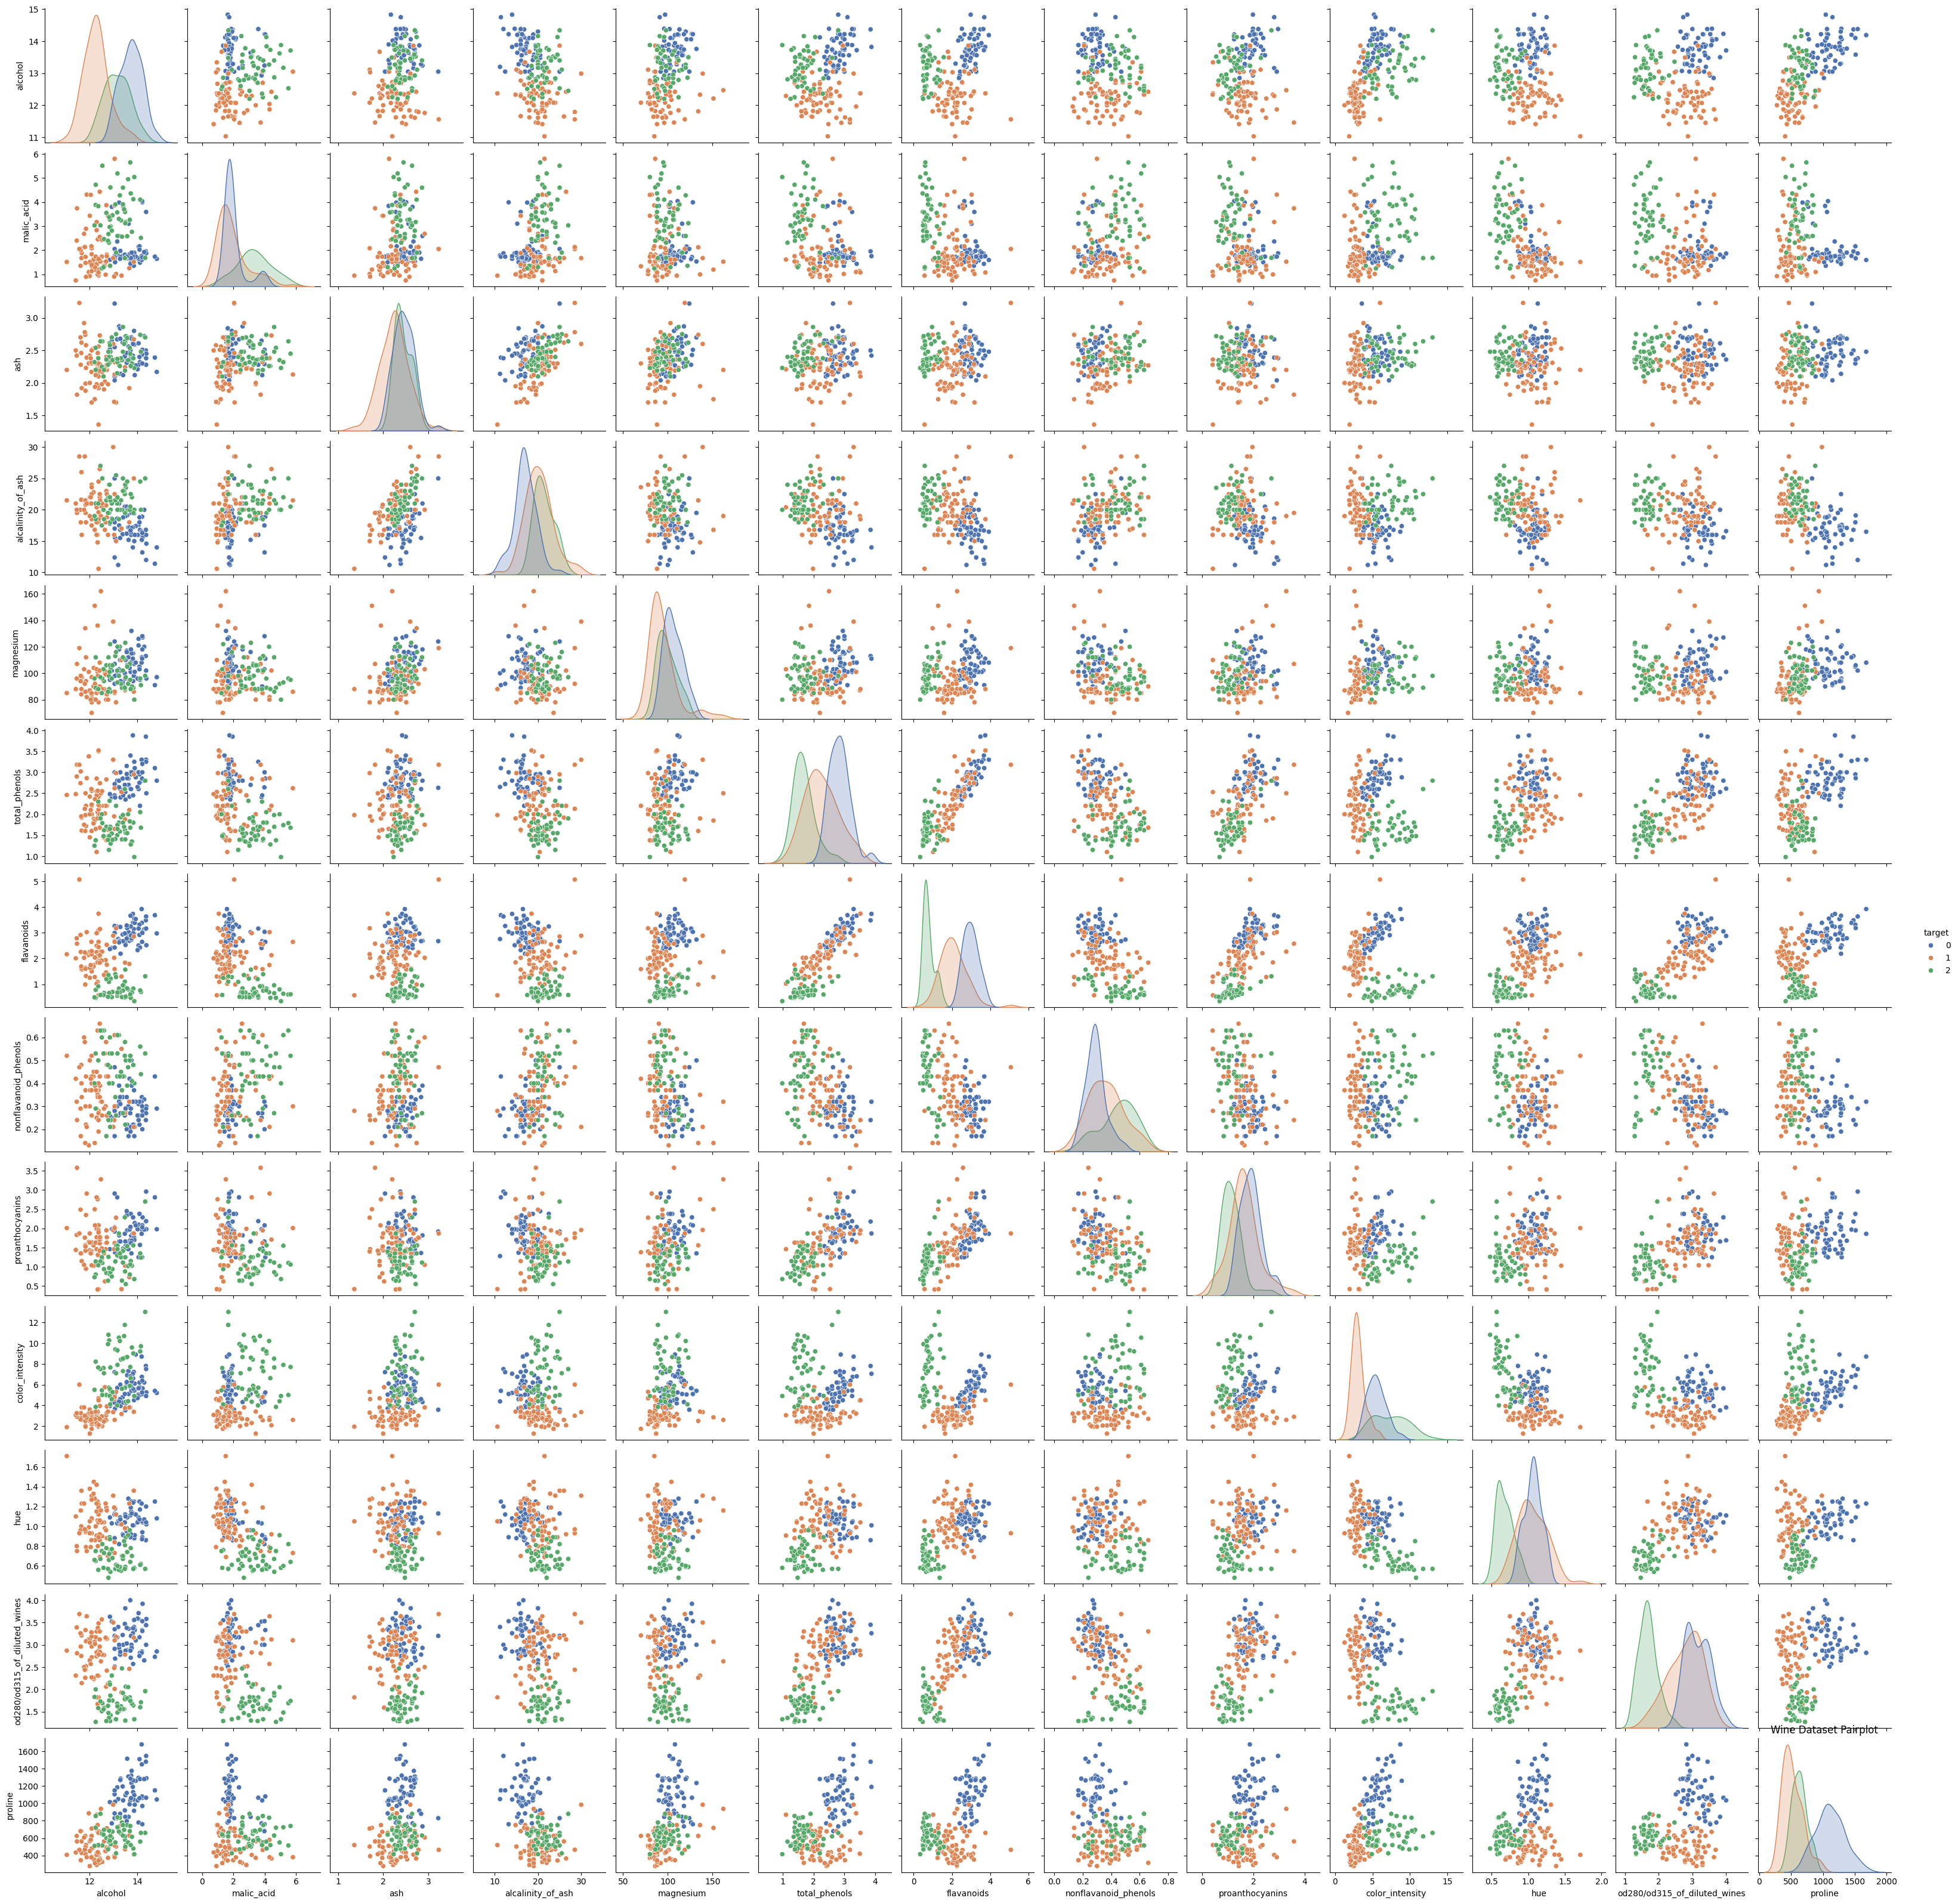

Confusion Matrix: Train Data
[[45  0  0]
 [ 0 57  0]
 [ 0  0 40]]

Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        40

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142

Confusion Matrix: Test Data
[[13  1  0]
 [ 0 14  0]
 [ 0  1  7]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

wine = load_wine()
X = wine.data  # Features
y = wine.target  # Target variable

# Create a DataFrame for better visualization
wine_df = pd.DataFrame(data=X, columns=wine.feature_names)
wine_df['target'] = y
wine_df.head()

sns.pairplot(wine_df, hue='target', palette='deep')
plt.title("Wine Dataset Pairplot")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

adaboost_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
adaboost_model.fit(X_train, y_train)

y_train_pred = adaboost_model.predict(X_train)
y_test_pred = adaboost_model.predict(X_test)

print("Confusion Matrix: Train Data")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report (Train):")
print(classification_report(y_train, y_train_pred))

print("============================================================================")

print("Confusion Matrix: Test Data")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))